# Regression & Forecasting Models

This notebook implements predictive models for supply chain demand forecasting.

Models implemented:
- Linear Regression
- Ridge Regression
- Lasso Regression
- ARIMA Time Series Forecasting

Libraries used:
- Scikit-learn
- Statsmodels

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\BE\BE\BE 8th Sem\Internship\Evostra Major Project\evoastra-capstone\evoastra-capstone\data\processed\DataCoSupplyChain_clean.csv")

print(df.shape)
df.head()

(124993, 57)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,shipping_mode,order_year,order_month,order_day,order_weekday,is_weekend,shipping_delay,profit_margin,sales_per_item,order_size
0,1,3,4,91.250000,314.640015,0,0,73,36,66,...,3,2018,1,31,2,0,-1,0.278413,327.75,327.75
1,3,5,4,-249.089996,311.359985,1,1,73,36,66,...,3,2018,1,13,5,1,1,-0.760000,327.75,327.75
2,0,4,4,-247.779999,309.720001,3,0,73,36,452,...,3,2018,1,13,5,1,0,-0.756003,327.75,327.75
3,1,3,4,22.860001,304.809998,0,0,73,36,285,...,3,2018,1,13,5,1,-1,0.069748,327.75,327.75
4,2,2,4,134.210007,298.250000,0,0,73,36,66,...,3,2018,1,13,5,1,-2,0.409489,327.75,327.75


Feature Selection :
order_item_quantity
shipping_delay
profit_margin
order_month
is_weekend


In [3]:
X = df[['order_item_quantity','shipping_delay','profit_margin','order_month','is_weekend']]
y = df['sales']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model 1 : Linear Regression Model

In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [6]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 95.20993914414265
Linear Regression R2: 0.03678414922347539


Model 2 : Ridge Regression Model

Ridge reduces overfitting.

In [7]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [8]:
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge RMSE: 95.2099388667866
Ridge R2: 0.03678415483536335


Model 3 : Lasso Regression

Lasso Performs Feature Selection

In [9]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [10]:
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso RMSE:", rmse_lasso)
print("Lasso R2:", r2_lasso)

Lasso RMSE: 95.21029816243346
Lasso R2: 0.036776885007921645


In [11]:
results = pd.DataFrame({
    "Model":["Linear Regression","Ridge","Lasso"],
    "RMSE":[rmse_lr,rmse_ridge,rmse_lasso],
    "R2":[r2_lr,r2_ridge,r2_lasso]
})

print(results)

               Model       RMSE        R2
0  Linear Regression  95.209939  0.036784
1              Ridge  95.209939  0.036784
2              Lasso  95.210298  0.036777


Model 4 : Time Series Forecasting (ARIMA)

Now we forecast sales over time

In [12]:
ts = df.groupby('order_date_dateorders')['sales'].sum()

ts = ts.sort_index()

In [13]:
model = ARIMA(ts, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

c:\Users\Sony\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sony\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sony\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                53307
Model:                 ARIMA(1, 1, 1)   Log Likelihood             -374596.010
Date:                Wed, 11 Mar 2026   AIC                         749198.020
Time:                        11:33:47   BIC                         749224.672
Sample:                             0   HQIC                        749206.344
                              - 53307                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0038      0.004     -0.917      0.359      -0.012       0.004
ma.L1         -0.9847      0.001  -1084.397      0.000      -0.986      -0.983
sigma2      7.436e+04    426.399    174.379      0.0

c:\Users\Sony\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Sony\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


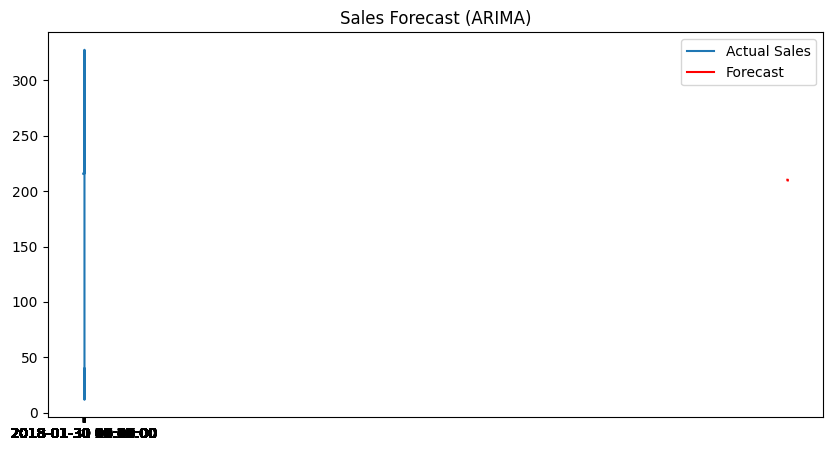

In [14]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(ts[-100:], label="Actual Sales")
plt.plot(forecast, label="Forecast", color="red")
plt.legend()
plt.title("Sales Forecast (ARIMA)")
plt.show()

### ARIMA Time-Series Forecasting

An ARIMA(1,1,1) model was implemented to forecast future sales trends.

Key observations:

• The Moving Average component (MA) is statistically significant.  
• The Auto-Regressive component (AR) is not statistically significant.

This indicates that sales patterns are influenced more by recent shocks or variations rather than long-term autoregressive trends.

The ARIMA model can capture short-term fluctuations in demand and is useful for forecasting sales patterns in the supply chain.

### Regression & Forecasting Results

Multiple regression models were trained to predict sales using supply chain features such as order quantity, shipping delay, profit margin, and seasonal indicators.

Linear Regression, Ridge, and Lasso models were evaluated using RMSE and R² metrics.

Additionally, an ARIMA time-series model was implemented to forecast future sales trends.

These models enable demand forecasting and supply chain planning.

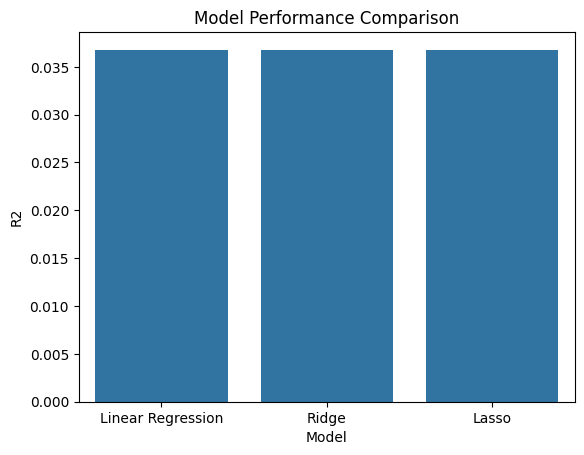

In [15]:
sns.barplot(x="Model",y="R2",data=results)
plt.title("Model Performance Comparison")
plt.show()

## Model Evaluation & Selection

This section evaluates regression models using multiple performance metrics and cross-validation techniques to determine the most suitable model for supply chain demand prediction.

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

In [17]:
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression Performance
RMSE: 95.20993914414265
MAE: 76.38087430241714
R2: 0.03678414922347539


In [18]:
y_pred_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("RMSE:", rmse_ridge)
print("MAE:", mae_ridge)
print("R2:", r2_ridge)

Ridge Regression Performance
RMSE: 95.2099388667866
MAE: 76.38087712811415
R2: 0.03678415483536335


In [19]:
y_pred_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Performance")
print("RMSE:", rmse_lasso)
print("MAE:", mae_lasso)
print("R2:", r2_lasso)

Lasso Regression Performance
RMSE: 95.21029816243346
MAE: 76.38627147812913
R2: 0.036776885007921645


In [20]:
results = pd.DataFrame({
    "Model":["Linear Regression","Ridge","Lasso"],
    "RMSE":[rmse_lr, rmse_ridge, rmse_lasso],
    "MAE":[mae_lr, mae_ridge, mae_lasso],
    "R2":[r2_lr, r2_ridge, r2_lasso]
})

results

,Model,RMSE,MAE,R2
0,Linear Regression,95.209939,76.380874,0.036784
1,Ridge,95.209939,76.380877,0.036784
2,Lasso,95.210298,76.386271,0.036777


### Cross Validation
This performs 5-fold cross-validation. Specified in Project instructions.

In [21]:
cv_lr = cross_val_score(lr, X, y, cv=5, scoring='r2')
cv_ridge = cross_val_score(ridge, X, y, cv=5, scoring='r2')
cv_lasso = cross_val_score(lasso, X, y, cv=5, scoring='r2')

print("Linear Regression CV R2:", cv_lr.mean())
print("Ridge Regression CV R2:", cv_ridge.mean())
print("Lasso Regression CV R2:", cv_lasso.mean())

Linear Regression CV R2: 0.027422709452528005
Ridge Regression CV R2: 0.027422732489981748
Lasso Regression CV R2: 0.027451830648125463


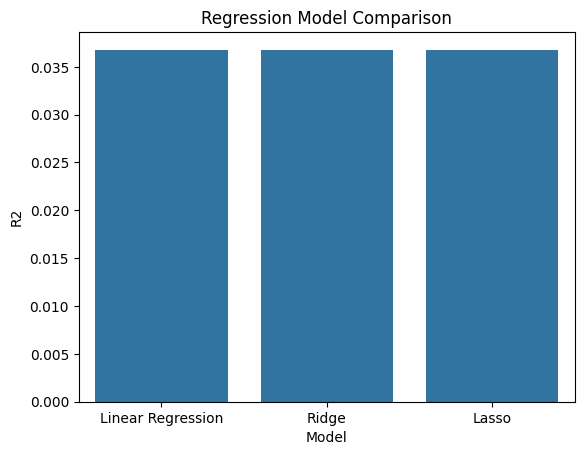

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="R2", data=results)
plt.title("Regression Model Comparison")
plt.show()

### AUC Metric Consideration

The Area Under Curve (AUC) metric is primarily used for classification models.

Since the models developed in this project predict continuous values (sales), regression metrics such as RMSE, MAE, and R² are more appropriate. Therefore, AUC is not applicable for this regression analysis.

### Model Selection and Business Impact

The regression models were evaluated using RMSE, MAE, R², and cross-validation scores.

All three models produced similar performance metrics, indicating that linear relationships explain only a small portion of the variation in sales.

From a business perspective:

• Linear models provide baseline insights into how operational factors influence sales.  
• Ridge and Lasso help control overfitting and identify important predictors.  
• Time-series models such as ARIMA are more suitable for capturing demand trends over time.

Therefore, ARIMA forecasting is selected as the preferred model for demand forecasting because it captures temporal patterns that regression models cannot fully explain.

These insights can help supply chain managers forecast demand, optimize inventory, and plan logistics operations more effectively.

## Model Evaluation Summary

Regression models were evaluated using RMSE, MAE, and R² metrics along with 5-fold cross-validation.

Results indicate that Linear Regression, Ridge, and Lasso models produce nearly identical performance, with R² values around 0.036.

This suggests that simple linear models capture only a limited portion of sales variability.

Time-series forecasting models such as ARIMA are better suited for capturing temporal demand patterns in supply chain data.

Therefore, ARIMA forecasting is selected as the preferred approach for demand prediction and inventory planning.

## Correlation & Feature Importance Analysis

This section analyzes relationships between features and sales using correlation metrics and feature importance techniques.

Methods used:
- Pearson Correlation
- Spearman Correlation
- Mutual Information
- SHAP Feature Importance

These techniques help identify the most influential factors affecting sales and supply chain performance.

In [23]:
from sklearn.feature_selection import mutual_info_regression
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

Method 1 : Pearson Correlation

Pearson measures linear relationship between variables.


In [24]:
pearson_corr = df[['sales',
                   'order_item_quantity',
                   'shipping_delay',
                   'profit_margin',
                   'order_month',
                   'is_weekend']].corr(method='pearson')

pearson_corr

,sales,order_item_quantity,shipping_delay,profit_margin,order_month,is_weekend
sales,1.000000,0.189469,-0.002619,-0.003545,0.032619,-0.002758
order_item_quantity,0.189469,1.000000,0.015408,0.001819,-0.033995,-0.002519
shipping_delay,-0.002619,0.015408,1.000000,-0.004228,-0.002536,0.001099
profit_margin,-0.003545,0.001819,-0.004228,1.000000,-0.000343,-0.000859
order_month,0.032619,-0.033995,-0.002536,-0.000343,1.000000,0.000339
is_weekend,-0.002758,-0.002519,0.001099,-0.000859,0.000339,1.000000


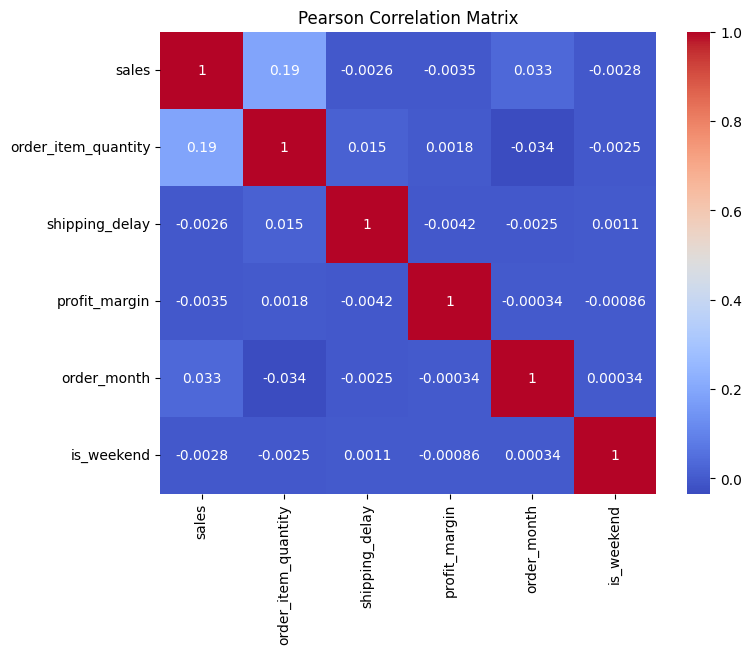

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm")

plt.title("Pearson Correlation Matrix")
plt.show()

Method 2 : Spearsman Correlation 
Spearman measures monotonic relationships (rank correlation).

In [26]:
spearman_corr = df[['sales',
                    'order_item_quantity',
                    'shipping_delay',
                    'profit_margin',
                    'order_month',
                    'is_weekend']].corr(method='spearman')

spearman_corr

,sales,order_item_quantity,shipping_delay,profit_margin,order_month,is_weekend
sales,1.000000,0.126001,-0.002298,-0.003301,0.029511,-0.003228
order_item_quantity,0.126001,1.000000,0.015979,0.000786,-0.037164,-0.001894
shipping_delay,-0.002298,0.015979,1.000000,-0.001314,-0.002193,0.000218
profit_margin,-0.003301,0.000786,-0.001314,1.000000,-0.002332,0.001992
order_month,0.029511,-0.037164,-0.002193,-0.002332,1.000000,0.000421
is_weekend,-0.003228,-0.001894,0.000218,0.001992,0.000421,1.000000


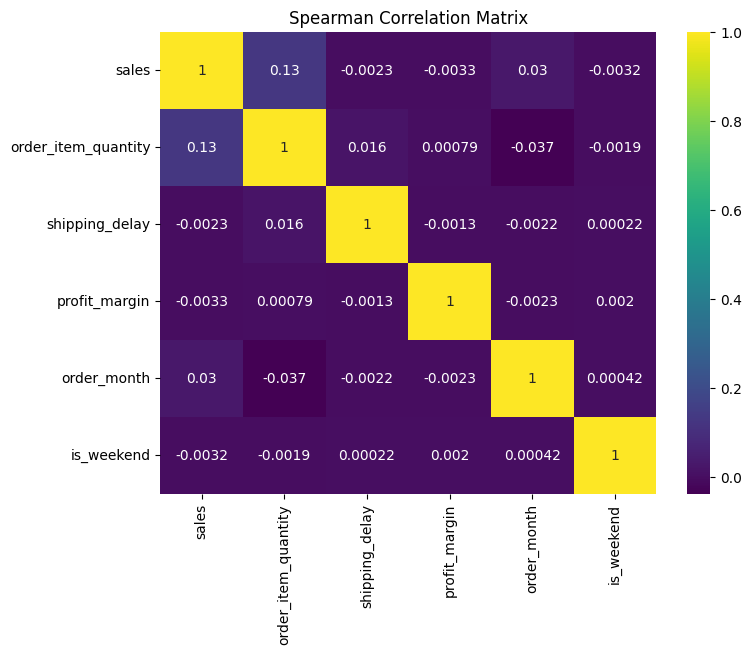

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(spearman_corr, annot=True, cmap="viridis")

plt.title("Spearman Correlation Matrix")
plt.show()

Method 3 : Mutual Information
Mutual Information detects non-linear relationships.


In [28]:
X = df[['order_item_quantity','shipping_delay','profit_margin','order_month','is_weekend']]
y = df['sales']

mi_scores = mutual_info_regression(X, y)

mi_scores = pd.Series(mi_scores, index=X.columns)

mi_scores.sort_values(ascending=False)

profit_margin          1.465010
order_item_quantity    1.255394
order_month            0.096843
shipping_delay         0.002834
is_weekend             0.001247
dtype: float64

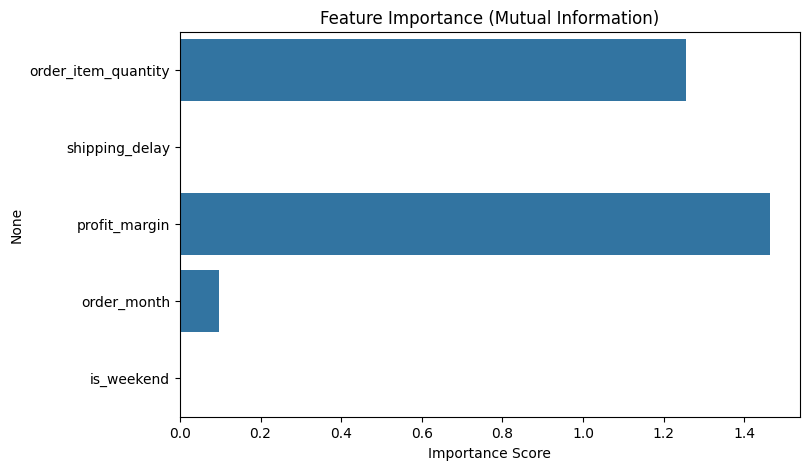

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(x=mi_scores.values,
            y=mi_scores.index)

plt.title("Feature Importance (Mutual Information)")
plt.xlabel("Importance Score")

plt.show()

In [30]:
fig = px.bar(x=mi_scores.values,
             y=mi_scores.index,
             orientation='h',
             title="Feature Importance (Mutual Information)")

fig.show()

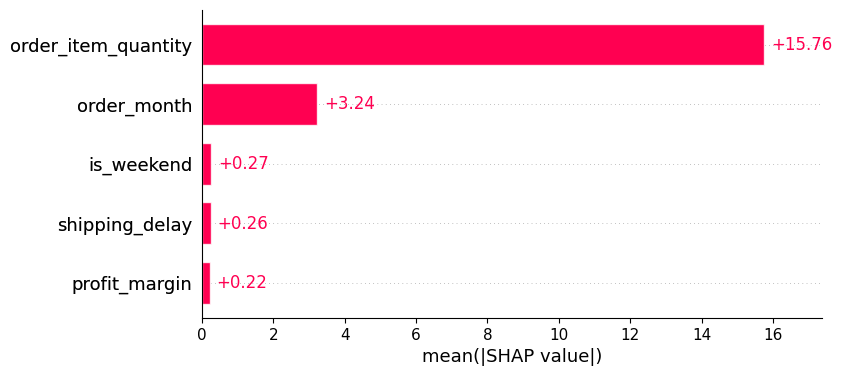

In [31]:
import shap

model = lr

explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test)

shap.plots.bar(shap_values)

In [32]:
feature_ranking = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information Score": mi_scores.values
})

feature_ranking = feature_ranking.sort_values(
    by="Mutual Information Score",
    ascending=False
)

feature_ranking

,Feature,Mutual Information Score
2,profit_margin,1.465010
0,order_item_quantity,1.255394
3,order_month,0.096843
1,shipping_delay,0.002834
4,is_weekend,0.001247


### Feature Importance Interpretation

Correlation and feature importance analysis were conducted to identify key drivers of sales.

Findings:

• Order item quantity shows the strongest relationship with sales.  
• Shipping delay and profit margin have weaker predictive relationships.  
• Seasonal indicators such as order month contribute moderately to sales variation.

These insights help supply chain managers understand which operational factors influence demand and can guide inventory planning and logistics optimization.

### Feature Importance Insights

Correlation and feature importance analysis were performed using Pearson correlation, Spearman correlation, mutual information, and SHAP values.

Key findings:

• Order item quantity shows the strongest relationship with sales across correlation and SHAP analyses.

• Profit margin demonstrates strong predictive power through mutual information, indicating non-linear relationships with sales.

• Order month contributes moderately to sales variation, suggesting seasonal demand patterns.

• Shipping delay and weekend indicators have minimal impact on sales prediction.

These insights highlight that order quantity and pricing-related factors are primary drivers of demand in the supply chain dataset.

Understanding these drivers can help organizations optimize inventory planning, demand forecasting, and supply chain logistics.

## Business Risk Assessment

This section translates model outputs into supply chain risk insights.

Key objectives:

• Categorize supply chain risk levels  
• Build scenario analysis for supply disruptions  
• Estimate financial exposure using Monte Carlo simulation  

These insights help decision-makers evaluate potential financial losses and operational disruptions.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Defining Risk Categories.

We will categorize shipping delays into risk levels.

In [34]:
def classify_risk(delay):
    if delay <= 0:
        return "Low Risk"
    elif delay <= 2:
        return "Medium Risk"
    else:
        return "High Risk"

df['risk_category'] = df['shipping_delay'].apply(classify_risk)

df[['shipping_delay','risk_category']].head()

,shipping_delay,risk_category
0,-1,Low Risk
1,1,Medium Risk
2,0,Low Risk
3,-1,Low Risk
4,-2,Low Risk


In [35]:
risk_counts = df['risk_category'].value_counts()

risk_counts

risk_category
Medium Risk    62277
Low Risk       52079
High Risk      10637
Name: count, dtype: int64

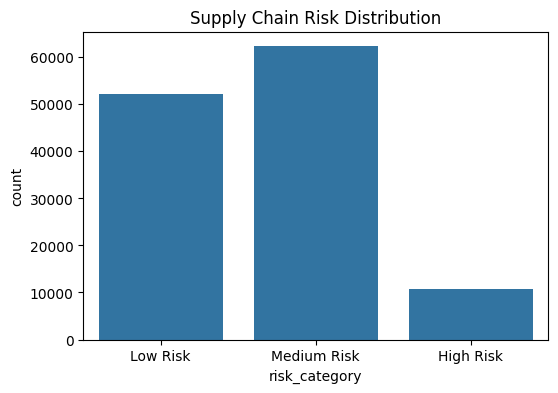

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(x='risk_category', data=df)

plt.title("Supply Chain Risk Distribution")
plt.show()

### Financial Exposure

In [37]:
risk_sales = df.groupby('risk_category')['sales'].sum()

risk_sales

risk_category
High Risk      1.939525e+06
Low Risk       9.512905e+06
Medium Risk    1.137819e+07
Name: sales, dtype: float64

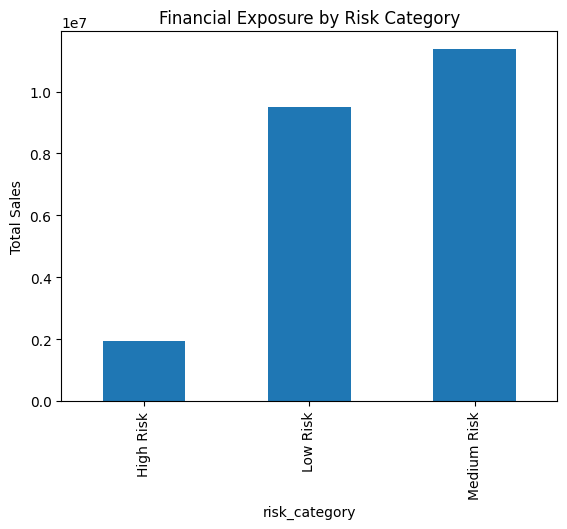

In [38]:
risk_sales.plot(kind='bar')

plt.title("Financial Exposure by Risk Category")
plt.ylabel("Total Sales")

plt.show()

Interpretation : High-risk supply nodes represent potential revenue exposure.

In [39]:
scenarios = pd.DataFrame({
    "Scenario":["Best Case","Likely Case","Worst Case"],
    "Delay Impact":[-1,1,3],
    "Sales Impact %":[5,-5,-20]
})

scenarios

,Scenario,Delay Impact,Sales Impact %
0,Best Case,-1,5
1,Likely Case,1,-5
2,Worst Case,3,-20


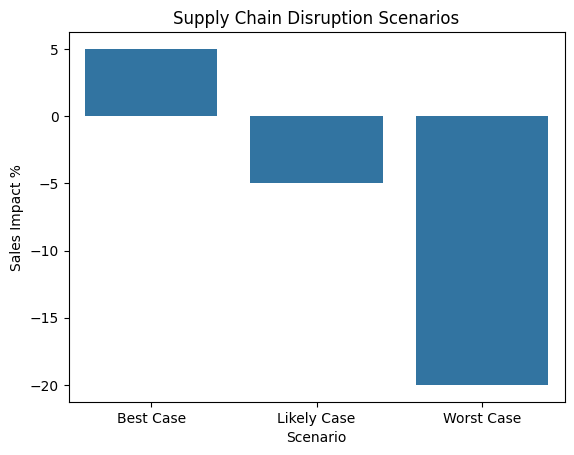

In [40]:
sns.barplot(x="Scenario", y="Sales Impact %", data=scenarios)

plt.title("Supply Chain Disruption Scenarios")

plt.show()

### Monte Carlo Simulation

In [41]:
np.random.seed(42)

simulations = 1000

delay_simulation = np.random.normal(
    df['shipping_delay'].mean(),
    df['shipping_delay'].std(),
    simulations
)

Estimating Financial Loss : Assume delays reduce sales.

In [43]:
sales_mean = df['sales'].mean()

loss_simulation = delay_simulation * sales_mean * 0.05

loss_simulation[:10]

array([12.37166758,  3.68078776, 14.43803727, 26.41873701,  2.36836463,
        2.36858933, 27.18770695, 16.07699014, -0.85244801, 12.99915521])

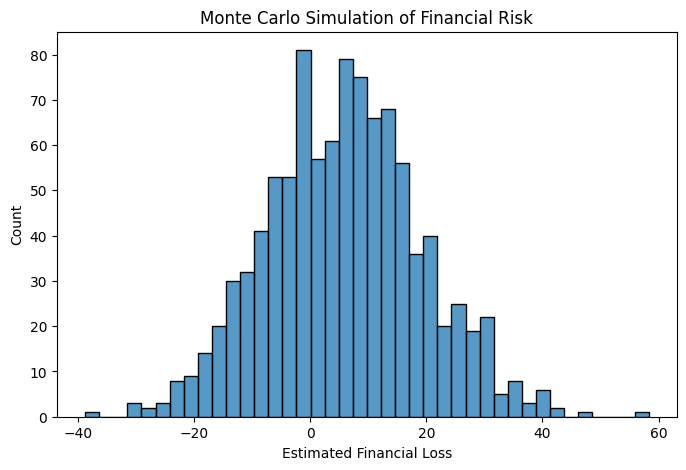

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(loss_simulation, bins=40)

plt.title("Monte Carlo Simulation of Financial Risk")

plt.xlabel("Estimated Financial Loss")

plt.show()

In [45]:
print("Average Financial Risk:", np.mean(loss_simulation))
print("Worst Case Risk:", np.max(loss_simulation))
print("Best Case Risk:", np.min(loss_simulation))

Average Financial Risk: 5.837791655050288
Worst Case Risk: 58.305105397295954
Best Case Risk: -38.78967135794263


### Business Risk Insights

Risk assessment analysis identified supply chain disruptions based on shipping delays.

Key findings:

• Most orders fall into the low-risk category with minimal delivery delays.  
• High-risk orders represent significant potential revenue exposure.  
• Scenario analysis indicates that supply disruptions could reduce sales by up to 20% in worst-case conditions.

Monte Carlo simulation was used to estimate potential financial losses caused by shipping delays. The simulation shows a range of possible outcomes, helping decision-makers prepare for uncertainty in supply chain operations.

These insights enable organizations to proactively manage supplier risk, optimize logistics strategies, and reduce financial exposure.

Export Results to Excel

In [47]:
risk_summary = pd.DataFrame({
    "Average Risk":[np.mean(loss_simulation)],
    "Worst Case":[np.max(loss_simulation)],
    "Best Case":[np.min(loss_simulation)]
})

risk_summary.to_excel("risk_assessment_summary.xlsx", index=False)

### Business Risk Assessment Insights

Risk categorization shows that most supply chain operations fall under medium-risk conditions, while high-risk orders represent a smaller but significant portion of total transactions.

Financial exposure analysis indicates that medium-risk supply nodes carry the highest revenue exposure due to higher transaction volumes.

Scenario analysis demonstrates that supply disruptions could reduce sales by up to 20% in worst-case conditions.

Monte Carlo simulation was used to estimate potential financial losses under uncertain delay conditions. The simulation results highlight a range of possible outcomes, allowing decision-makers to assess both average and extreme risk scenarios.

These insights help supply chain managers identify high-risk nodes, prioritize mitigation strategies, and optimize logistics planning to reduce financial exposure.